In [1]:
from datasets import load_dataset
import pandas as pd
dataset = load_dataset("electricsheepafrica/nigerian-banking-bnpl")
df = dataset["train"].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

nigerian_bnpl_full.parquet:   0%|          | 0.00/74.0M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         object        
 1   purchase_date          datetime64[ns]
 2   customer_id            object        
 3   merchant_category      object        
 4   merchant_name          object        
 5   customer_state         object        
 6   principal_ngn          float64       
 7   interest_rate_monthly  float64       
 8   tenor_days             int64         
 9   num_installments       int64         
 10  provider               object        
 11  credit_score           int64         
 12  first_time_customer    bool          
 13  first_payment_due      datetime64[ns]
 14  default_30d            bool          
 15  default_90d            bool          
dtypes: bool(3), datetime64[ns](2), float64(2), int64(3), object(6)
memory usage: 204.1+ MB


In [3]:
df.isna().sum()

,0
transaction_id,0
purchase_date,0
customer_id,0
merchant_category,0
merchant_name,0
customer_state,0
principal_ngn,0
interest_rate_monthly,0
tenor_days,0
num_installments,0


In [4]:
df.head()

,transaction_id,purchase_date,customer_id,merchant_category,merchant_name,customer_state,principal_ngn,interest_rate_monthly,tenor_days,num_installments,provider,credit_score,first_time_customer,first_payment_due,default_30d,default_90d
0,BNPL-0000274330,2024-07-10,CUS-00036437,groceries,Groceries Store 105,Oyo,35416.989135,0.000000,14,1,FairMoney,645,False,2024-08-09,False,False
1,BNPL-0001873807,2023-08-01,CUS-00131005,furniture,Furniture Store 820,Lagos,43154.846706,0.000000,30,1,FairMoney,716,True,2023-08-31,False,False
2,BNPL-0001029126,2022-02-12,CUS-00648656,electronics,Electronics Store 346,Abuja (FCT),247235.615112,0.000000,14,1,Branch,470,False,2022-03-14,False,False
3,BNPL-0001512791,2023-01-26,CUS-00611557,furniture,Furniture Store 393,Lagos,70679.217230,0.032728,30,1,Branch,620,False,2023-02-25,False,False
4,BNPL-0000552055,2023-01-12,CUS-00499951,fashion,Fashion Store 956,Ekiti,225083.504313,0.049655,90,3,Branch,536,False,2023-02-11,False,False


In this notebook we have two main and two side predictions. This is a mix of two regression and two classification problems:

Main questions:
1) Classification: Can we predict whether a transaction will default within 90 days?
2) Regression: Can we predict a customer's credit score from origination information?

Side questions:

3) Classification: Can we predict whether a transaction will default within 30 days?

4) Regression: Can we predict the principal amount (principal_ngn)?


Some important things that should be mentioned:
- The data is split by time using `purchase_date`: oldest 70% train, next 15% validation, newest 15% test
- Cross-validation is done only on the training set using 5-fold `TimeSeriesSplit`
- `transaction_id` and `customer_id` are not used as model features
- `merchant_name` is dropped because it can have many unique values and may make the notebook harder to explain
- `first_time_customer` is encoded using `OneHotEncoder()` mainly for practice and experimentation

# Problem 1

## Question
Can we predict whether a transaction will default within **90 days** using information available around loan origination?

## Target
`default_90d`

## Model
**Logistic Regression**

## Why this model?
Logistic Regression is a good baseline classification model. Super easy to explain. Works well with scaled numeric features and encoded categorical features. Also gives predicted probabilities that can be used for ROC/AUC.

## Evaluation metrics
For classification, this notebook uses Accuracy, Precision, Recall, F1 score, Confusion Matrix, and ROC/AUC.


## Feature engineering
This main model uses engineered date features:
- purchase month
- purchase quarter
- purchase day of week
- weekend purchase flag
- days until first payment


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

#Separate copy of df
problem1_df = df.copy()

#Convert date columns
problem1_df["purchase_date"] = pd.to_datetime(problem1_df["purchase_date"], errors="coerce")
problem1_df["first_payment_due"] = pd.to_datetime(problem1_df["first_payment_due"], errors="coerce")

#Sort by time so the train/validation/test split is realistic
problem1_df = problem1_df.sort_values("purchase_date").reset_index(drop=True)

#Engineered date features
problem1_df["purchase_month"] = problem1_df["purchase_date"].dt.month
problem1_df["purchase_quarter"] = problem1_df["purchase_date"].dt.quarter
problem1_df["purchase_dayofweek"] = problem1_df["purchase_date"].dt.dayofweek
problem1_df["is_weekend"] = problem1_df["purchase_dayofweek"].isin([5, 6]).astype(int)
problem1_df["days_until_first_payment"] = (
    problem1_df["first_payment_due"] - problem1_df["purchase_date"]
).dt.days

#Drop rows where the target is missing
problem1_df = problem1_df.dropna(subset=["default_90d"])

#Convert boolean target to 0/1
problem1_df["default_90d"] = problem1_df["default_90d"].astype(int)

#Feature columns for this model
#We don't use transaction_id, customer_id, merchant_name, default_30d, or default_90d as features.
problem1_numeric_features = [
    "principal_ngn", "interest_rate_monthly", "tenor_days", "num_installments",
    "credit_score", "purchase_month", "purchase_quarter", "purchase_dayofweek",
    "is_weekend", "days_until_first_payment"
]

problem1_categorical_features = [
    "merchant_category", "customer_state", "provider", "first_time_customer"
]

problem1_features = problem1_numeric_features + problem1_categorical_features

X_problem1 = problem1_df[problem1_features]
y_problem1 = problem1_df["default_90d"]

print("Problem 1 feature columns:")
print(problem1_features)
print("\nTarget balance:")
print(y_problem1.value_counts(normalize=True))

Problem 1 feature columns:
['principal_ngn', 'interest_rate_monthly', 'tenor_days', 'num_installments', 'credit_score', 'purchase_month', 'purchase_quarter', 'purchase_dayofweek', 'is_weekend', 'days_until_first_payment', 'merchant_category', 'customer_state', 'provider', 'first_time_customer']

Target balance:
default_90d
0    0.919999
1    0.080001
Name: proportion, dtype: float64


In [6]:
# Time-based train/validation/test split
n_rows = len(problem1_df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

X1_train = X_problem1.iloc[:train_end]
y1_train = y_problem1.iloc[:train_end]

X1_val = X_problem1.iloc[train_end:val_end]
y1_val = y_problem1.iloc[train_end:val_end]

X1_test = X_problem1.iloc[val_end:]
y1_test = y_problem1.iloc[val_end:]

print("Train shape:", X1_train.shape)
print("Validation shape:", X1_val.shape)
print("Test shape:", X1_test.shape)

Train shape: (1400000, 14)
Validation shape: (300000, 14)
Test shape: (300000, 14)


In [7]:
#Preprocessing for numeric and categorical columns
problem1_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

problem1_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # OneHotEncoder is used on first_time_customer mainly for practice and experimentation. We know it isn't necesary
    # A boolean column could also be converted to 0/1, but using OneHotEncoder helps practice sklearn preprocessing.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

problem1_preprocessor = ColumnTransformer(transformers=[
    ("num", problem1_numeric_transformer, problem1_numeric_features),
    ("cat", problem1_categorical_transformer, problem1_categorical_features)
], sparse_threshold=0)

problem1_model = Pipeline(steps=[
    ("preprocessor", problem1_preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

#5-fold cross-validation on the training set only
problem1_cv = TimeSeriesSplit(n_splits=5)
problem1_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

problem1_cv_results = cross_validate(
    problem1_model,
    X1_train,
    y1_train,
    cv=problem1_cv,
    scoring=problem1_scoring,
    n_jobs=-1
)

problem1_cv_summary = pd.DataFrame(problem1_cv_results).mean().to_frame("Mean CV Score")
display(problem1_cv_summary)

,Mean CV Score
fit_time,12.407492
score_time,2.085971
test_accuracy,0.829016
test_precision,0.304345
test_recall,0.886314
test_f1,0.453069
test_roc_auc,0.916273


In [8]:
#Fitting the model on the training data
problem1_model.fit(X1_train, y1_train)

#Validation predictions
problem1_val_pred = problem1_model.predict(X1_val)
problem1_val_proba = problem1_model.predict_proba(X1_val)[:, 1]

#Test predictions
problem1_test_pred = problem1_model.predict(X1_test)
problem1_test_proba = problem1_model.predict_proba(X1_test)[:, 1]

#Validation and test metrics
problem1_results = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "Accuracy": [
        accuracy_score(y1_val, problem1_val_pred),
        accuracy_score(y1_test, problem1_test_pred)
    ],
    "Precision": [
        precision_score(y1_val, problem1_val_pred, zero_division=0),
        precision_score(y1_test, problem1_test_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y1_val, problem1_val_pred, zero_division=0),
        recall_score(y1_test, problem1_test_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y1_val, problem1_val_pred, zero_division=0),
        f1_score(y1_test, problem1_test_pred, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y1_val, problem1_val_proba),
        roc_auc_score(y1_test, problem1_test_proba)
    ]
})

display(problem1_results)

,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Validation,0.828393,0.304588,0.887421,0.453517,0.916371
1,Test,0.829050,0.304326,0.887126,0.453187,0.916546


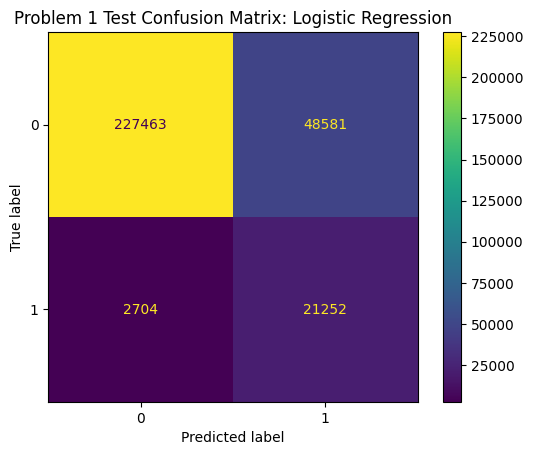

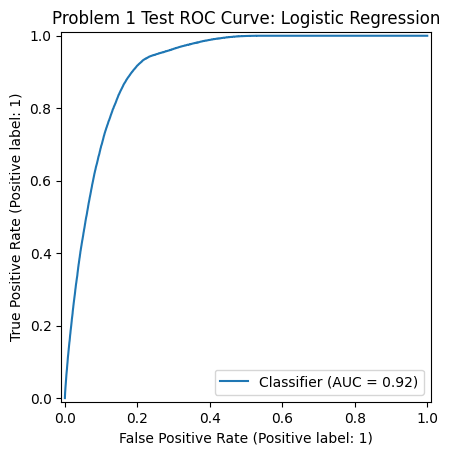

,Dataset,Accuracy,F1,ROC_AUC
0,Train,0.828390,0.452837,0.916471
1,Validation,0.828393,0.453517,0.916371


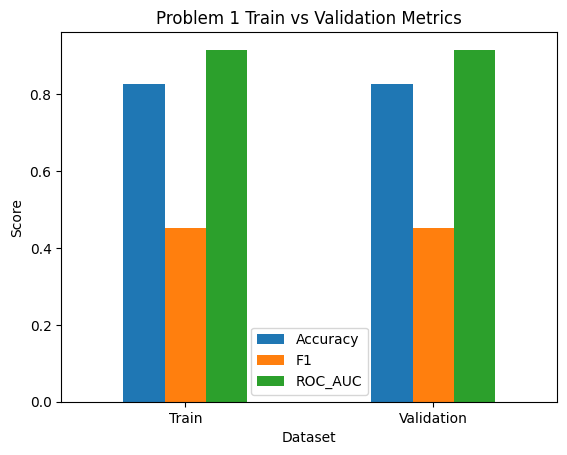

In [9]:
#Confusion matrix on test set
problem1_cm = confusion_matrix(y1_test, problem1_test_pred)
ConfusionMatrixDisplay(problem1_cm).plot()
plt.title("Problem 1 Test Confusion Matrix: Logistic Regression")
plt.show()

# ROC curve on test set
RocCurveDisplay.from_predictions(y1_test, problem1_test_proba)
plt.title("Problem 1 Test ROC Curve: Logistic Regression")
plt.show()

#Simple train vs validation to check for overfitting
problem1_train_pred = problem1_model.predict(X1_train)
problem1_train_proba = problem1_model.predict_proba(X1_train)[:, 1]

problem1_overfit_check = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Accuracy": [accuracy_score(y1_train, problem1_train_pred), accuracy_score(y1_val, problem1_val_pred)],
    "F1": [f1_score(y1_train, problem1_train_pred, zero_division=0), f1_score(y1_val, problem1_val_pred, zero_division=0)],
    "ROC_AUC": [roc_auc_score(y1_train, problem1_train_proba), roc_auc_score(y1_val, problem1_val_proba)]
})

display(problem1_overfit_check)
problem1_overfit_check.set_index("Dataset")[["Accuracy", "F1", "ROC_AUC"]].plot(kind="bar")
plt.title("Problem 1 Train vs Validation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**bold text**# Problem 2

## Question
Can we predict a customer's **credit score** from loan, merchant, and transaction information available around origination?

## Target
`credit_score`

## Model
**Gradient Boosting Regressor**

## Why this model?
Gradient Boosting Regression is good for tabular data like this becasue it capture nonlinear relationships between features. This makes it a stronger regression model than a basic linear baseline when the relationship is not perfectly straight-line.

## Evaluation metrics
For regression, this notebook uses MAE, MSE, RMSE, and R².

## Feature engineering
This main model uses the same easy-to-explain date features as Problem 1.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Separate copy
problem2_df = df.copy()

#Convert date columns
problem2_df["purchase_date"] = pd.to_datetime(problem2_df["purchase_date"], errors="coerce")
problem2_df["first_payment_due"] = pd.to_datetime(problem2_df["first_payment_due"], errors="coerce")

#Sort by time
problem2_df = problem2_df.sort_values("purchase_date").reset_index(drop=True)

#Eengineered date features
problem2_df["purchase_month"] = problem2_df["purchase_date"].dt.month
problem2_df["purchase_quarter"] = problem2_df["purchase_date"].dt.quarter
problem2_df["purchase_dayofweek"] = problem2_df["purchase_date"].dt.dayofweek
problem2_df["is_weekend"] = problem2_df["purchase_dayofweek"].isin([5, 6]).astype(int)
problem2_df["days_until_first_payment"] = (
    problem2_df["first_payment_due"] - problem2_df["purchase_date"]
).dt.days

#Drop rows w/o target
problem2_df = problem2_df.dropna(subset=["credit_score"])

#Feature columns for this model
#credit_score is the target, so it is not used as a feature.
problem2_numeric_features = [
    "principal_ngn", "interest_rate_monthly", "tenor_days", "num_installments",
    "purchase_month", "purchase_quarter", "purchase_dayofweek",
    "is_weekend", "days_until_first_payment"
]

problem2_categorical_features = [
    "merchant_category", "customer_state", "provider", "first_time_customer"
]

problem2_features = problem2_numeric_features + problem2_categorical_features

X_problem2 = problem2_df[problem2_features]
y_problem2 = problem2_df["credit_score"]

print("Problem 2 feature columns:")
print(problem2_features)
print("\nCredit score summary:")
display(y_problem2.describe())

Problem 2 feature columns:
['principal_ngn', 'interest_rate_monthly', 'tenor_days', 'num_installments', 'purchase_month', 'purchase_quarter', 'purchase_dayofweek', 'is_weekend', 'days_until_first_payment', 'merchant_category', 'customer_state', 'provider', 'first_time_customer']

Credit score summary:


,credit_score
count,2.000000e+06
mean,6.195104e+02
std,8.475805e+01
min,3.000000e+02
25%,5.620000e+02
50%,6.200000e+02
75%,6.770000e+02
max,8.500000e+02


In [11]:
#train/validation/test split
n_rows = len(problem2_df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

X2_train = X_problem2.iloc[:train_end]
y2_train = y_problem2.iloc[:train_end]

X2_val = X_problem2.iloc[train_end:val_end]
y2_val = y_problem2.iloc[train_end:val_end]

X2_test = X_problem2.iloc[val_end:]
y2_test = y_problem2.iloc[val_end:]

print("Train shape:", X2_train.shape)
print("Validation shape:", X2_val.shape)
print("Test shape:", X2_test.shape)

Train shape: (1400000, 13)
Validation shape: (300000, 13)
Test shape: (300000, 13)


In [12]:
# Preprocessing
problem2_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

problem2_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # OneHotEncoder is included for practice and experimentation with categorical/boolean preprocessing.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

problem2_preprocessor = ColumnTransformer(transformers=[
    ("num", problem2_numeric_transformer, problem2_numeric_features),
    ("cat", problem2_categorical_transformer, problem2_categorical_features)
], sparse_threshold=0)

problem2_model = Pipeline(steps=[
    ("preprocessor", problem2_preprocessor),
    ("model", GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=3))
])

# 5-fold cross-validation on the training set only
problem2_cv = TimeSeriesSplit(n_splits=5)
problem2_scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

problem2_cv_results = cross_validate(
    problem2_model,
    X2_train,
    y2_train,
    cv=problem2_cv,
    scoring=problem2_scoring,
    n_jobs=-1
)

problem2_cv_summary = pd.DataFrame({
    "Mean CV MAE": [-problem2_cv_results["test_MAE"].mean()],
    "Mean CV MSE": [-problem2_cv_results["test_MSE"].mean()],
    "Mean CV RMSE": [np.sqrt(-problem2_cv_results["test_MSE"].mean())],
    "Mean CV R2": [problem2_cv_results["test_R2"].mean()]
})

display(problem2_cv_summary)

KeyboardInterrupt: 

In [ ]:
#Fit model
problem2_model.fit(X2_train, y2_train)

#Validation and test predictions
problem2_val_pred = problem2_model.predict(X2_val)
problem2_test_pred = problem2_model.predict(X2_test)

#Validation and test metrics
problem2_results = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "MAE": [
        mean_absolute_error(y2_val, problem2_val_pred),
        mean_absolute_error(y2_test, problem2_test_pred)
    ],
    "MSE": [
        mean_squared_error(y2_val, problem2_val_pred),
        mean_squared_error(y2_test, problem2_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y2_val, problem2_val_pred)),
        np.sqrt(mean_squared_error(y2_test, problem2_test_pred))
    ],
    "R2": [
        r2_score(y2_val, problem2_val_pred),
        r2_score(y2_test, problem2_test_pred)
    ]
})

display(problem2_results)

In [ ]:
# Predicted vs actual plot on test set
plt.scatter(y2_test, problem2_test_pred, alpha=0.3)
plt.title("Problem 2 Test Set: Actual vs Predicted Credit Score")
plt.xlabel("Actual Credit Score")
plt.ylabel("Predicted Credit Score")
plt.show()

#Residual plot on test set
problem2_residuals = y2_test - problem2_test_pred
plt.scatter(problem2_test_pred, problem2_residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Problem 2 Test Set: Residual Plot")
plt.xlabel("Predicted Credit Score")
plt.ylabel("Residual")
plt.show()

#Simple train vs validation overfitting check
problem2_train_pred = problem2_model.predict(X2_train)

problem2_overfit_check = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "MAE": [mean_absolute_error(y2_train, problem2_train_pred), mean_absolute_error(y2_val, problem2_val_pred)],
    "RMSE": [
        np.sqrt(mean_squared_error(y2_train, problem2_train_pred)),
        np.sqrt(mean_squared_error(y2_val, problem2_val_pred))
    ],
    "R2": [r2_score(y2_train, problem2_train_pred), r2_score(y2_val, problem2_val_pred)]
})

display(problem2_overfit_check)
problem2_overfit_check.set_index("Dataset")[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Problem 2 Train vs Validation Error")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

# Problem 3

## Question
Can we segment customers into **Low**, **Medium**, and **High** risk groups based on their loan profile?

## Target
Unsupervised — risk tier is assigned after clustering based on the resulting cluster profiles.

## Model
**K-Means Clustering** (k=3)

## Why this model?
K-Means naturally partitions customers into non-overlapping groups based on feature similarity. With k=3 we get three actionable tiers that map to Low / Medium / High risk.

## Evaluation metrics
Silhouette Score, Davies-Bouldin Index, and cluster profile inspection to confirm the risk ordering makes intuitive sense.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Separate copy
problem3_df = df.copy()

# Convert date columns
problem3_df["purchase_date"] = pd.to_datetime(problem3_df["purchase_date"], errors="coerce")
problem3_df["first_payment_due"] = pd.to_datetime(problem3_df["first_payment_due"], errors="coerce")

# Sort by time
problem3_df = problem3_df.sort_values("purchase_date").reset_index(drop=True)

# Date features
problem3_df["purchase_month"] = problem3_df["purchase_date"].dt.month
problem3_df["purchase_quarter"] = problem3_df["purchase_date"].dt.quarter
problem3_df["purchase_dayofweek"] = problem3_df["purchase_date"].dt.dayofweek
problem3_df["is_weekend"] = problem3_df["purchase_dayofweek"].isin([5, 6]).astype(int)
problem3_df["days_until_first_payment"] = (
    problem3_df["first_payment_due"] - problem3_df["purchase_date"]
).dt.days

# Drop rows missing key features
problem3_df = problem3_df.dropna(subset=["credit_score", "principal_ngn"])

problem3_numeric_features = [
    "principal_ngn", "interest_rate_monthly", "tenor_days", "num_installments",
    "credit_score", "purchase_month", "purchase_quarter", "purchase_dayofweek",
    "is_weekend", "days_until_first_payment"
]

problem3_categorical_features = [
    "merchant_category", "customer_state", "provider", "first_time_customer"
]

problem3_features = problem3_numeric_features + problem3_categorical_features
X_problem3 = problem3_df[problem3_features]

print("Problem 3 feature columns:")
print(problem3_features)
print("\nDataset shape:", X_problem3.shape)

Problem 3 feature columns:
['principal_ngn', 'interest_rate_monthly', 'tenor_days', 'num_installments', 'credit_score', 'purchase_month', 'purchase_quarter', 'purchase_dayofweek', 'is_weekend', 'days_until_first_payment', 'merchant_category', 'customer_state', 'provider', 'first_time_customer']

Dataset shape: (2000000, 14)


In [20]:
# Preprocessing
problem3_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

problem3_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

problem3_preprocessor = ColumnTransformer(transformers=[
    ("num", problem3_numeric_transformer, problem3_numeric_features),
    ("cat", problem3_categorical_transformer, problem3_categorical_features)
], sparse_threshold=0)

# Fit K-Means with k=3 — one cluster per risk tier
X3_processed = problem3_preprocessor.fit_transform(X_problem3)
problem3_model = KMeans(n_clusters=3, random_state=42, n_init=10)
problem3_df["cluster"] = problem3_model.fit_predict(X3_processed)

# Evaluation metrics
sil = silhouette_score(X3_processed, problem3_df["cluster"], sample_size=5000, random_state=42)
dbi = davies_bouldin_score(X3_processed, problem3_df["cluster"])

problem3_metrics = pd.DataFrame({
    "Metric": ["Silhouette Score (higher is better)", "Davies-Bouldin Index (lower is better)"],
    "Value": [round(sil, 4), round(dbi, 4)]
})
display(problem3_metrics)

# Assign risk labels: rank clusters by mean credit score — lowest score = highest risk
cluster_means = problem3_df.groupby("cluster")["credit_score"].mean()
risk_map = dict(zip(cluster_means.sort_values().index, ["High", "Medium", "Low"]))
problem3_df["risk_tier"] = problem3_df["cluster"].map(risk_map)

print("\nRisk tier distribution:")
print(problem3_df["risk_tier"].value_counts())

,Metric,Value
0,Silhouette Score (higher is better),0.1565
1,Davies-Bouldin Index (lower is better),2.0579



Risk tier distribution:
risk_tier
Low       925984
Medium    556825
High      517191
Name: count, dtype: int64


,credit_score,principal_ngn,interest_rate_monthly,tenor_days
risk_tier,,,,
Low,619.59,49962.15,0.03,25.08
Medium,619.49,50020.35,0.03,70.77
High,619.39,49960.83,0.03,34.78


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


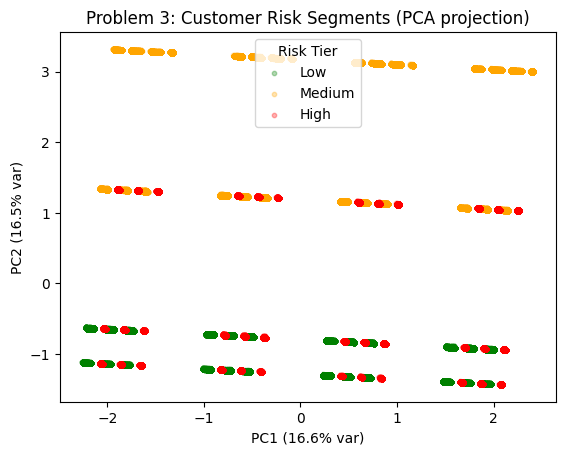

In [21]:
# Cluster profile summary
tier_order = ["Low", "Medium", "High"]
display(
    problem3_df.groupby("risk_tier")[[
        "credit_score", "principal_ngn", "interest_rate_monthly", "tenor_days"
    ]].mean().round(2).reindex(tier_order)
)

# PCA scatter coloured by risk tier
pca = PCA(n_components=2, random_state=42)
X3_pca = pca.fit_transform(X3_processed)

color_map = {"Low": "green", "Medium": "orange", "High": "red"}
for tier, color in color_map.items():
    mask = problem3_df["risk_tier"] == tier
    plt.scatter(X3_pca[mask, 0], X3_pca[mask, 1], c=color, label=tier, alpha=0.3, s=10)

plt.title("Problem 3: Customer Risk Segments (PCA projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.legend(title="Risk Tier")
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Build a working dataframe from the Problem 1 test set
problem3_df = problem1_df.iloc[val_end:].copy()
problem3_df["default_prob"] = problem1_test_proba

# Assign risk tiers by percentile of predicted default probability
p50 = problem3_df["default_prob"].quantile(0.50)
p80 = problem3_df["default_prob"].quantile(0.80)

def assign_tier(p):
    if p <= p50:
        return "Low"
    elif p <= p80:
        return "Medium"
    else:
        return "High"

problem3_df["risk_tier"] = problem3_df["default_prob"].apply(assign_tier)

print(f"Thresholds — Low/Medium cutoff: {p50:.3f}, Medium/High cutoff: {p80:.3f}")
print("\nRisk tier distribution:")
print(problem3_df["risk_tier"].value_counts())

Thresholds — Low/Medium cutoff: 0.113, Medium/High cutoff: 0.577

Risk tier distribution:
risk_tier
Low       150000
Medium     90000
High       60000
Name: count, dtype: int64


,count,actual_default_rate,mean_credit_score,mean_default_prob
risk_tier,,,,
Low,150000,0.001,668.373,0.032
Medium,90000,0.045,595.108,0.298
High,60000,0.331,533.911,0.811


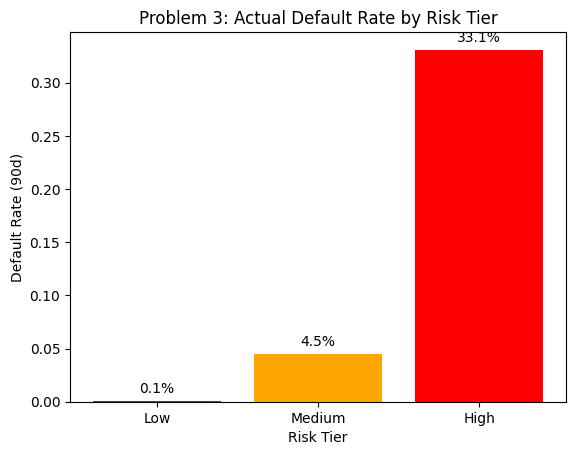

In [24]:
# Validate: actual default rate and mean credit score should separate across tiers
tier_order = ["Low", "Medium", "High"]

validation = problem3_df.groupby("risk_tier").agg(
    count=("default_90d", "count"),
    actual_default_rate=("default_90d", "mean"),
    mean_credit_score=("credit_score", "mean"),
    mean_default_prob=("default_prob", "mean")
).round(3).reindex(tier_order)

display(validation)

# Plot: actual default rate by tier
colors = ["green", "orange", "red"]
bars = plt.bar(tier_order, validation["actual_default_rate"], color=colors)
for bar, val in zip(bars, validation["actual_default_rate"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.1%}", ha="center", va="bottom")
plt.title("Problem 3: Actual Default Rate by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Default Rate (90d)")
plt.show()